# 06 Model Training and Comparison RESET
Trains Logistic Regression, Random Forest, XGBoost if installed, and Isolation Forest.
Uses laptop-safe defaults. Threshold/event-level evaluation comes in Step 7.



In [2]:
import sys, json, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings('ignore')
try:
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, IsolationForest
    from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, average_precision_score, roc_auc_score, confusion_matrix, precision_recall_curve
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Install required packages with: %pip install scikit-learn xgboost joblib') from exc
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE=True
except Exception as exc:
    XGBOOST_AVAILABLE=False; XGBOOST_ERROR=exc
print('Python:', sys.executable)
print('XGBoost available:', XGBOOST_AVAILABLE)



Python: c:\Users\user\Desktop\metropt_predictive_maintenance_starter\.venv\Scripts\python.exe
XGBoost available: True


In [3]:
RANDOM_STATE=42
PRIMARY_TARGET='warning_12h'
MAX_TRAIN_ROWS_FOR_FITTING=50000
RF_N_ESTIMATORS=50
XGB_N_ESTIMATORS=80
print('Training sample cap:', MAX_TRAIN_ROWS_FOR_FITTING)



Training sample cap: 50000


In [4]:
current_dir=Path.cwd()
PROJECT_ROOT=current_dir.parent if current_dir.name=='notebooks' else current_dir
PROCESSED_DATA_DIR=PROJECT_ROOT/'data'/'processed'
SPLIT_DATA_DIR=PROCESSED_DATA_DIR/'splits'
OUTPUT_TABLES_DIR=PROJECT_ROOT/'outputs'/'tables'
OUTPUT_FIGURES_DIR=PROJECT_ROOT/'outputs'/'figures'
OUTPUT_PREDICTIONS_DIR=PROJECT_ROOT/'outputs'/'predictions'
MODELS_DIR=PROJECT_ROOT/'models'
for p in [OUTPUT_TABLES_DIR, OUTPUT_FIGURES_DIR, OUTPUT_PREDICTIONS_DIR, MODELS_DIR]: p.mkdir(parents=True, exist_ok=True)



In [5]:
def read_y(path): return pd.read_csv(path)[PRIMARY_TARGET].astype(int)
files={'X_train':SPLIT_DATA_DIR/'X_train_12h.csv','y_train':SPLIT_DATA_DIR/'y_train_12h.csv','X_val':SPLIT_DATA_DIR/'X_validation_12h.csv','y_val':SPLIT_DATA_DIR/'y_validation_12h.csv','X_test':SPLIT_DATA_DIR/'X_test_12h.csv','y_test':SPLIT_DATA_DIR/'y_test_12h.csv','validation_full':SPLIT_DATA_DIR/'validation_12h.csv','test_full':SPLIT_DATA_DIR/'test_12h.csv'}
missing=[k for k,p in files.items() if not p.exists()]
if missing: raise FileNotFoundError(f'Missing {missing}. Run Step 5 first.')
X_train = pd.read_csv(files['X_train'])
y_train = read_y(files['y_train'])

X_val = pd.read_csv(files['X_val'])
y_val = read_y(files['y_val'])

X_test = pd.read_csv(files['X_test'])
y_test = read_y(files['y_test'])

validation_full = pd.read_csv(files['validation_full'])
test_full = pd.read_csv(files['test_full'])

# ---------------------------------------------------------
# Remove accidental CSV index columns from modelling data
# ---------------------------------------------------------
INDEX_LIKE_COLUMNS = ['Unnamed: 0', 'Unnamed__0']

for df_name, df in [
    ('X_train', X_train),
    ('X_val', X_val),
    ('X_test', X_test)
]:
    cols_to_remove = [c for c in INDEX_LIKE_COLUMNS if c in df.columns]

    if cols_to_remove:
        df.drop(columns=cols_to_remove, inplace=True)
        print(f'Removed {cols_to_remove} from {df_name}')
    else:
        print(f'No index-like column found in {df_name}')

# Safety check
remaining_bad_cols = [
    c for c in X_train.columns
    if str(c).startswith('Unnamed')
]

assert len(remaining_bad_cols) == 0, (
    f'Index-like columns still present: {remaining_bad_cols}'
)

print(
    'X_train:', X_train.shape,
    'X_val:', X_val.shape,
    'X_test:', X_test.shape
)

if len(X_val) == 0:
    raise ValueError('Validation set is empty. Rerun Step 5.')



Removed ['Unnamed: 0'] from X_train
Removed ['Unnamed: 0'] from X_val
Removed ['Unnamed: 0'] from X_test
X_train: (875435, 114) X_val: (262969, 114) X_test: (348590, 114)


In [6]:
def safe_name(name):
    s=str(name)
    for ch in ['[',']','<','>','{','}',':',',','/','\\',' ']: s=s.replace(ch,'_')
    return s
seen={}; safe_cols=[]
for c in X_train.columns:
    b=safe_name(c)
    if b in seen: seen[b]+=1; b=f'{b}_{seen[b]}'
    else: seen[b]=0
    safe_cols.append(b)
pd.DataFrame({'original_feature_name':X_train.columns,'safe_feature_name':safe_cols}).to_csv(OUTPUT_TABLES_DIR/'model_feature_name_mapping.csv', index=False)
X_train.columns=safe_cols; X_val.columns=safe_cols; X_test.columns=safe_cols
for X in [X_train, X_val, X_test]:
    for c in X.columns: X[c]=pd.to_numeric(X[c], errors='coerce')
    X.replace([np.inf,-np.inf], np.nan, inplace=True)
X_train=X_train.astype('float32'); X_val=X_val.astype('float32'); X_test=X_test.astype('float32')
with open(MODELS_DIR/'model_feature_columns.json','w') as f: json.dump(safe_cols, f, indent=2)
print('Features:', len(safe_cols))



Features: 114


In [7]:
def sample_fit(X,y,max_rows):
    if len(X)<=max_rows: return X.copy(), y.copy()
    pos=y[y==1].index; neg=y[y==0].index
    n_neg=max(max_rows-len(pos), 0)
    neg_sample=pd.Series(neg).sample(n=min(n_neg,len(neg)), random_state=RANDOM_STATE).values if n_neg>0 else []
    idx=pd.Index(np.concatenate([pos.values, neg_sample])).sort_values()
    return X.loc[idx].copy(), y.loc[idx].copy()
X_fit,y_fit=sample_fit(X_train,y_train,MAX_TRAIN_ROWS_FOR_FITTING)
fit_summary=pd.DataFrame([{'training_rows_original':len(X_train),'training_rows_used_for_fitting':len(X_fit),'positive_rows_used':int(y_fit.sum()),'normal_rows_used':int((y_fit==0).sum())}])
fit_summary.to_csv(OUTPUT_TABLES_DIR/'model_fitting_sample_summary.csv', index=False)
fit_summary



,training_rows_original,training_rows_used_for_fitting,positive_rows_used,normal_rows_used
0,875435,50000,7939,42061


In [9]:
def pr_auc(y,s):
    return average_precision_score(y,s) if len(np.unique(y))>1 else np.nan
def roc_auc(y,s):
    return roc_auc_score(y,s) if len(np.unique(y))>1 else np.nan
def metrics(y,score,pred,model,strategy):
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {'model':model,'threshold_strategy':strategy,'precision':precision_score(y,pred,zero_division=0),'recall':recall_score(y,pred,zero_division=0),'f1':f1_score(y,pred,zero_division=0),'f2':fbeta_score(y,pred,beta=2,zero_division=0),'pr_auc':pr_auc(y,score),'roc_auc':roc_auc(y,score),'true_negative':int(tn),'false_positive':int(fp),'false_negative':int(fn),'true_positive':int(tp)}
def model_key(name): return name.lower().replace(' ','_').replace('-','_')



In [10]:
logistic=Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler()),('model',LogisticRegression(class_weight='balanced',max_iter=1000,C=1.0,solver='liblinear',random_state=RANDOM_STATE))])
print('Training Logistic Regression...'); logistic.fit(X_fit,y_fit); joblib.dump(logistic, MODELS_DIR/'logistic_regression_model.joblib')
rf=Pipeline([('imputer',SimpleImputer(strategy='median')),('model',RandomForestClassifier(n_estimators=RF_N_ESTIMATORS,max_depth=12,min_samples_leaf=5,max_features='sqrt',class_weight='balanced_subsample',n_jobs=-1,random_state=RANDOM_STATE))])
print('Training Random Forest...'); rf.fit(X_fit,y_fit); joblib.dump(rf, MODELS_DIR/'random_forest_model.joblib')
models={'Logistic Regression':logistic,'Random Forest':rf}
trained_xgb=False
if XGBOOST_AVAILABLE:
    spw=int((y_fit==0).sum())/max(int(y_fit.sum()),1)
    xgb=Pipeline([('imputer',SimpleImputer(strategy='median')),('model',XGBClassifier(n_estimators=XGB_N_ESTIMATORS,learning_rate=0.05,max_depth=4,subsample=0.8,colsample_bytree=0.8,objective='binary:logistic',eval_metric='logloss',scale_pos_weight=spw,tree_method='hist',n_jobs=-1,random_state=RANDOM_STATE))])
    print('Training XGBoost...'); xgb.fit(X_fit,y_fit); joblib.dump(xgb, MODELS_DIR/'xgboost_model.joblib'); models['XGBoost']=xgb; trained_xgb=True
else:
    print('Skipping XGBoost.')



Training Logistic Regression...
Training Random Forest...
Training XGBoost...


In [11]:
normal=X_fit.loc[y_fit==0].copy()
if len(normal)>50000: normal=normal.sample(n=50000, random_state=RANDOM_STATE)
iso_imputer=SimpleImputer(strategy='median')
normal_imp=iso_imputer.fit_transform(normal)
contamination=max(0.001,min(0.10,float(y_fit.mean()) if y_fit.mean()>0 else 0.01))
iso=IsolationForest(n_estimators=150, contamination=contamination, n_jobs=-1, random_state=RANDOM_STATE)
print('Training Isolation Forest...'); iso.fit(normal_imp)
iso_bundle={'imputer':iso_imputer,'model':iso,'feature_names':safe_cols,'contamination':contamination}
joblib.dump(iso_bundle, MODELS_DIR/'isolation_forest_model.joblib')



Training Isolation Forest...


['c:\\Users\\user\\Desktop\\metropt_predictive_maintenance_starter\\metropt_predictive_maintenance_starter\\models\\isolation_forest_model.joblib']

In [18]:
val_pred = pd.DataFrame({'y_true': y_val.values})
test_pred = pd.DataFrame({'y_true': y_test.values})

if 'timestamp' in validation_full.columns:
    val_pred.insert(0, 'timestamp', validation_full['timestamp'].values)

if 'timestamp' in test_full.columns:
    test_pred.insert(0, 'timestamp', test_full['timestamp'].values)

for c in ['warning_12h_event_id', 'failure_event_id']:
    if c in validation_full.columns:
        val_pred[c] = validation_full[c].values
    if c in test_full.columns:
        test_pred[c] = test_full[c].values

val_metrics = []
test_metrics = []

for name, model in models.items():
    print('Scoring', name)

    key = model_key(name)

    vs = model.predict_proba(X_val)[:, 1]
    ts = model.predict_proba(X_test)[:, 1]

    vp = (vs >= 0.5).astype(int)
    tp = (ts >= 0.5).astype(int)

    val_pred[f'{key}_score'] = vs
    val_pred[f'{key}_pred_default_0_50'] = vp

    test_pred[f'{key}_score'] = ts
    test_pred[f'{key}_pred_default_0_50'] = tp

    val_metrics.append(
        metrics(y_val, vs, vp, name, 'default 0.50')
    )

    test_metrics.append(
        metrics(y_test, ts, tp, name, 'default 0.50')
    )

val_imp = iso_bundle['imputer'].transform(X_val)
test_imp = iso_bundle['imputer'].transform(X_test)

val_raw = -iso_bundle['model'].decision_function(val_imp)
test_raw = -iso_bundle['model'].decision_function(test_imp)

iso_min = np.nanmin(val_raw)
iso_max = np.nanmax(val_raw)

if iso_max <= iso_min:
    raise ValueError('Invalid Isolation Forest validation score range.')

vs = (val_raw - iso_min) / (iso_max - iso_min)
ts = (test_raw - iso_min) / (iso_max - iso_min)

vs = np.clip(vs, 0.0, 1.0)
ts = np.clip(ts, 0.0, 1.0)

vp = (iso_bundle['model'].predict(val_imp) == -1).astype(int)
tp = (iso_bundle['model'].predict(test_imp) == -1).astype(int)

val_pred['isolation_forest_score'] = vs
val_pred['isolation_forest_pred_default'] = vp

test_pred['isolation_forest_score'] = ts
test_pred['isolation_forest_pred_default'] = tp

val_metrics.append(
    metrics(
        y_val,
        vs,
        vp,
        'Isolation Forest',
        'contamination threshold'
    )
)

test_metrics.append(
    metrics(
        y_test,
        ts,
        tp,
        'Isolation Forest',
        'contamination threshold'
    )
)

val_pred.to_csv(
    OUTPUT_PREDICTIONS_DIR / 'validation_predictions_all_models.csv',
    index=False
)

test_pred.to_csv(
    OUTPUT_PREDICTIONS_DIR / 'test_predictions_all_models.csv',
    index=False
)

print('Isolation Forest validation scale:', iso_min, iso_max)
print('Validation score range:', vs.min(), vs.max())
print('Test score range:', ts.min(), ts.max())



Scoring Logistic Regression
Scoring Random Forest
Scoring XGBoost
Isolation Forest validation scale: -0.15384020220086136 0.21584088500677856
Validation score range: 0.0 1.0
Test score range: 0.0029614018532630724 0.9433115658229123


In [19]:
val_comp=pd.DataFrame(val_metrics).sort_values(['f2','pr_auc'], ascending=False)
test_comp=pd.DataFrame(test_metrics).sort_values(['f2','pr_auc'], ascending=False)
val_comp.to_csv(OUTPUT_TABLES_DIR/'validation_model_comparison_record_level.csv', index=False)
test_comp.to_csv(OUTPUT_TABLES_DIR/'test_default_model_comparison_record_level.csv', index=False)
val_comp



,model,threshold_strategy,precision,recall,f1,f2,pr_auc,roc_auc,true_negative,false_positive,false_negative,true_positive
0,Logistic Regression,default 0.50,0.010794,0.335704,0.020915,0.047819,0.017088,0.433923,124533,134078,2895,1463
3,Isolation Forest,contamination threshold,0.002017,0.013309,0.003503,0.006279,0.010479,0.292272,229912,28699,4300,58
2,XGBoost,default 0.50,0.000000,0.000000,0.000000,0.000000,0.013837,0.455985,249856,8755,4358,0
1,Random Forest,default 0.50,0.000000,0.000000,0.000000,0.000000,0.013825,0.447049,256404,2207,4358,0


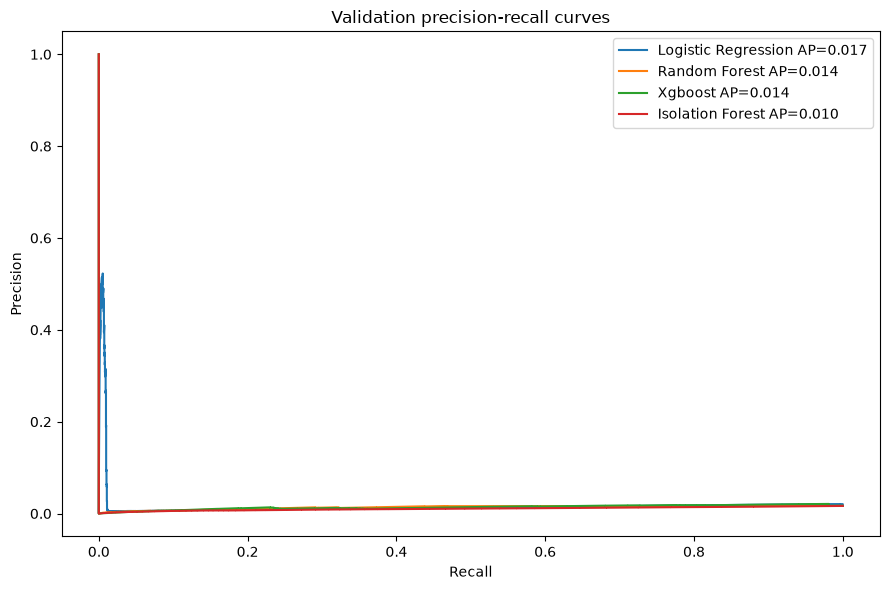

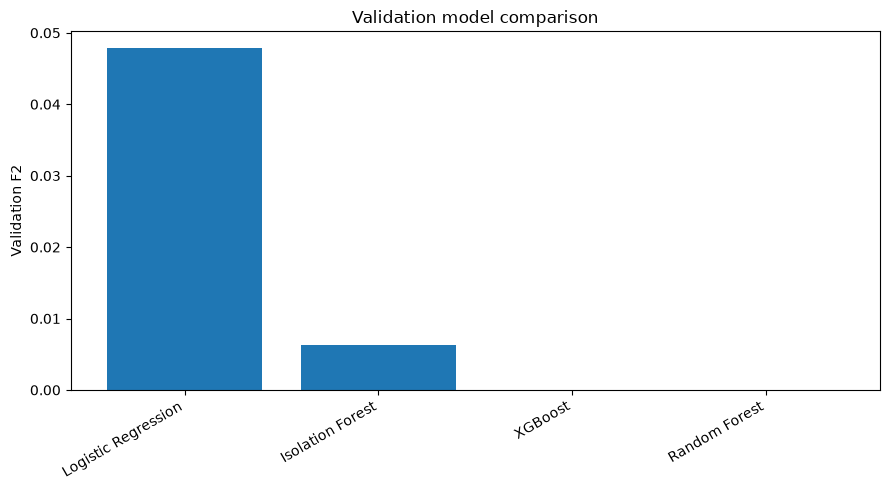

In [14]:
plt.figure(figsize=(9,6))
for col in [c for c in val_pred.columns if c.endswith('_score')]:
    p,r,_=precision_recall_curve(val_pred['y_true'], val_pred[col]); ap=average_precision_score(val_pred['y_true'], val_pred[col])
    plt.plot(r,p,label=f"{col.replace('_score','').replace('_',' ').title()} AP={ap:.3f}")
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Validation precision-recall curves'); plt.legend(); plt.tight_layout(); plt.savefig(OUTPUT_FIGURES_DIR/'validation_precision_recall_curves.png', dpi=300); plt.show()
plt.figure(figsize=(9,5)); plt.bar(val_comp['model'], val_comp['f2']); plt.ylabel('Validation F2'); plt.xticks(rotation=30, ha='right'); plt.title('Validation model comparison'); plt.tight_layout(); plt.savefig(OUTPUT_FIGURES_DIR/'validation_model_comparison_f2.png', dpi=300); plt.show()



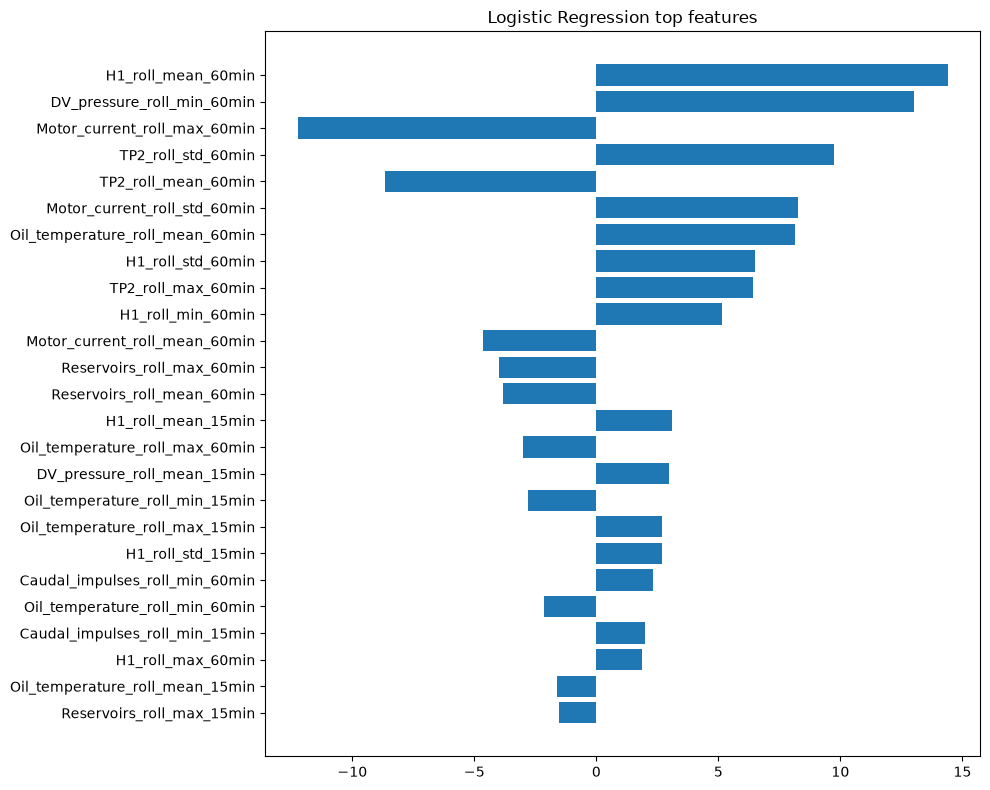

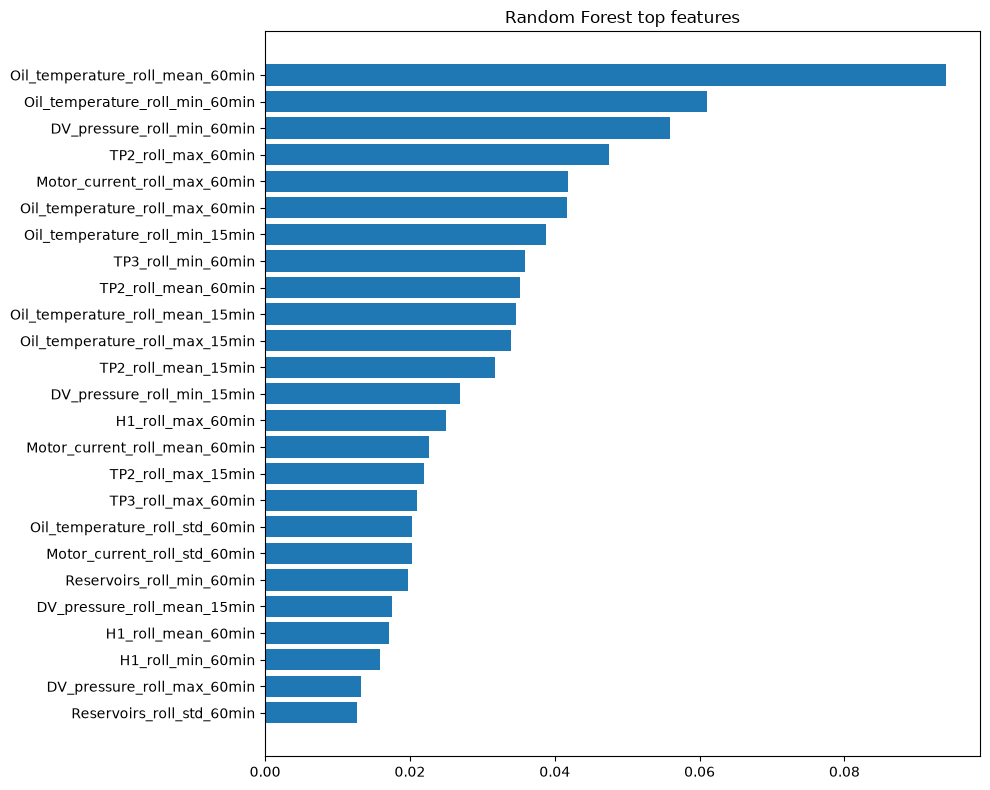

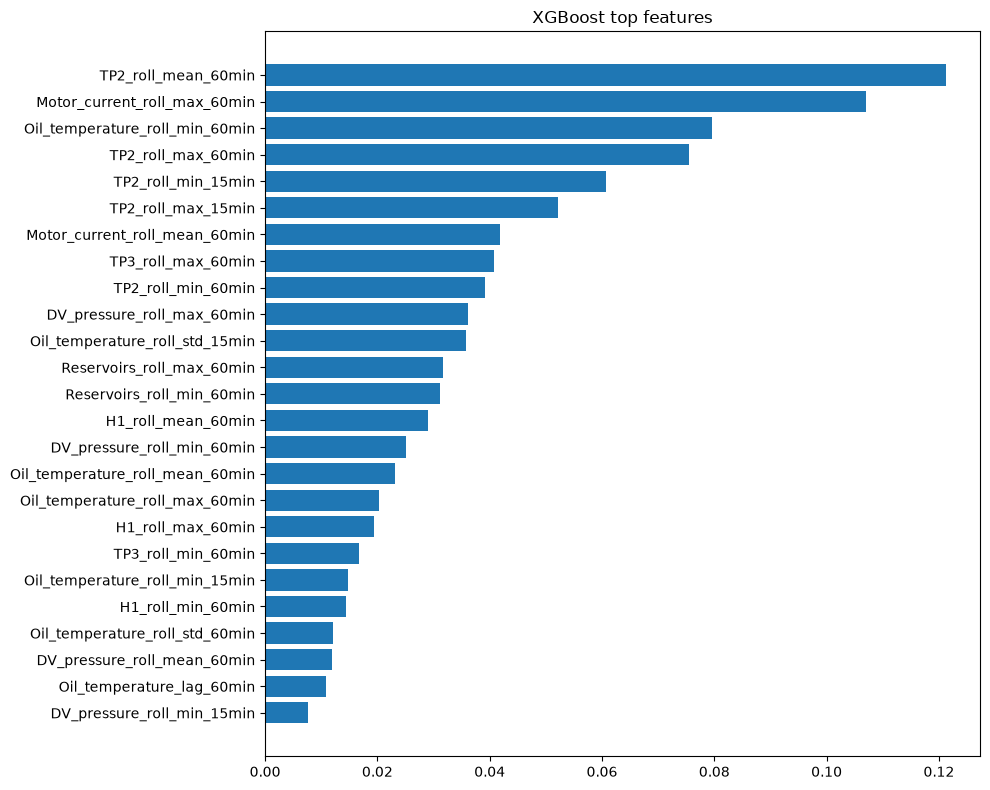

In [15]:
def save_imp(vals,names,title,prefix):
    d=pd.DataFrame({'feature':names,'importance':vals}); d['absolute_importance']=d['importance'].abs(); d=d.sort_values('absolute_importance', ascending=False); d.to_csv(OUTPUT_TABLES_DIR/f'{prefix}_top_feature_importance.csv', index=False)
    top=d.head(25).sort_values('absolute_importance')
    plt.figure(figsize=(10,8)); plt.barh(top['feature'], top['importance']); plt.title(title); plt.tight_layout(); plt.savefig(OUTPUT_FIGURES_DIR/f'{prefix}_top_feature_importance.png', dpi=300); plt.show()
save_imp(logistic.named_steps['model'].coef_[0], safe_cols, 'Logistic Regression top features','logistic_regression')
save_imp(rf.named_steps['model'].feature_importances_, safe_cols, 'Random Forest top features','random_forest')
if trained_xgb: save_imp(xgb.named_steps['model'].feature_importances_, safe_cols, 'XGBoost top features','xgboost')



In [16]:
registry=[]
for name, file, typ in [('Logistic Regression','logistic_regression_model.joblib','supervised'),('Random Forest','random_forest_model.joblib','supervised'),('Isolation Forest','isolation_forest_model.joblib','anomaly')]: registry.append({'model':name,'model_file':str(MODELS_DIR/file),'model_type':typ})
if trained_xgb: registry.append({'model':'XGBoost','model_file':str(MODELS_DIR/'xgboost_model.joblib'),'model_type':'supervised'})
model_registry=pd.DataFrame(registry); model_registry.to_csv(OUTPUT_TABLES_DIR/'model_registry.csv', index=False)
train_summary=pd.DataFrame({'item':['Primary target','Models trained','Training rows available','Training rows used','Validation rows','Test rows','Feature columns','Next step'], 'value':[PRIMARY_TARGET, ', '.join(model_registry['model']), len(X_train), len(X_fit), len(X_val), len(X_test), len(safe_cols), 'Step 7 threshold selection and event-level evaluation']})
train_summary.to_csv(OUTPUT_TABLES_DIR/'model_training_summary.csv', index=False)
checklist=pd.DataFrame({'task':['Split files loaded','Models trained','Validation predictions saved','Test predictions saved','Comparison tables saved','Feature importance saved'], 'status':['Complete','Complete','Complete','Complete','Complete','Complete']})
checklist.to_csv(OUTPUT_TABLES_DIR/'model_training_completion_checklist.csv', index=False)
print('Step 6 complete.')
train_summary


Step 6 complete.


,item,value
0,Primary target,warning_12h
1,Models trained,"Logistic Regression, Random Forest, Isolation ..."
2,Training rows available,875435
3,Training rows used,50000
4,Validation rows,262969
5,Test rows,348590
6,Feature columns,114
7,Next step,Step 7 threshold selection and event-level eva...


In [17]:
val_comp

,model,threshold_strategy,precision,recall,f1,f2,pr_auc,roc_auc,true_negative,false_positive,false_negative,true_positive
0,Logistic Regression,default 0.50,0.010794,0.335704,0.020915,0.047819,0.017088,0.433923,124533,134078,2895,1463
3,Isolation Forest,contamination threshold,0.002017,0.013309,0.003503,0.006279,0.010479,0.292272,229912,28699,4300,58
2,XGBoost,default 0.50,0.000000,0.000000,0.000000,0.000000,0.013837,0.455985,249856,8755,4358,0
1,Random Forest,default 0.50,0.000000,0.000000,0.000000,0.000000,0.013825,0.447049,256404,2207,4358,0
